In [56]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [57]:
class Dataset:
    def __init__(self, alpha=0.3,
                 xmin=0, tmin=0,
                 xmax=1, tmax=1,
                 Nx=100, Nt=50,
                 m=1, n=1):
        self.m, self.n = m, n
        self.alpha = alpha
        self.tmin = tmin
        self.xmin = xmin
        self.tmax = tmax
        self.xmax = xmax

        self.x_1d = np.linspace(xmin, xmax, Nx)
        self.t_1d = np.linspace(tmin, tmax, Nt)
        self.x, self.t = np.meshgrid(self.x_1d, self.t_1d)
        self.calculate_solution()

    def calculate_solution(self):
        self.solution = np.exp(-self.n**2 * np.pi**2 * self.alpha * self.t / self.m**2) * np.sin(self.n * np.pi * self.x / self.m)

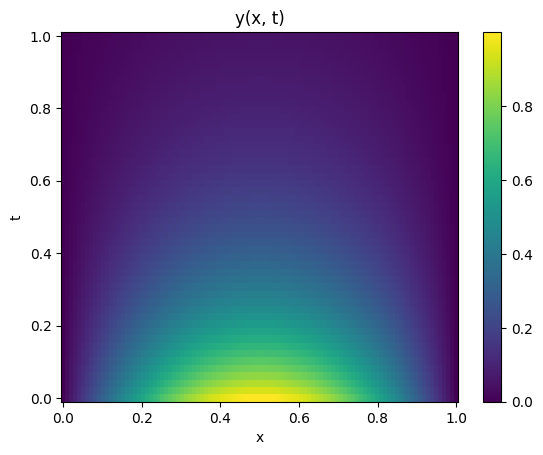

In [58]:
data = Dataset(m=1, n=1)

plt.pcolormesh(data.x, data.t, data.solution, shading='auto')
plt.colorbar()
plt.xlabel('x')
plt.ylabel('t')
plt.title('y(x, t)')
plt.show()

In [59]:
class SomeModel(nn.Module):
    def __init__(self,
                input_size = 2,
                nnodes = 10,
                output_size = 1,
                nlayers = 4,
                 activation=nn.Tanh(),
                 ):
        super().__init__()
        self.activation = activation
        self.nlayers = nlayers
        self.nnodes = nnodes

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(nnodes, nnodes) for _ in range(nlayers-1)
        ])

        self.output_layer = nn.Linear(nnodes, output_size)
        self.apply(self._init_weights_xavier)


    def _init_weights_xavier(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)


    def forward(self, x):
        if x.dtype == torch.float64:
            x = x.float()
        x = self.activation(self.dense0(x))

        for layer in self.hidden_layers:
            x = self.activation(layer(x))

        x = self.output_layer(x)

        return x

In [60]:
class Batch_bc:
    def __init__(self, x, t, values):
        x = x.flatten()
        t = t.flatten()
        self.grid = torch.from_numpy(np.vstack((x, t)).T).float().to(device)
        self.u = torch.from_numpy(values.flatten()).float().unsqueeze(1).to(device)

    def generate_points(self, N):
        indices = torch.randperm(self.grid.shape[0])[:N]
        self.points = self.grid[indices]
        self.values = self.u[indices]
        self.points.requires_grad = True

In [61]:
class Batch:
    def __init__(self, data: Dataset):
        x = data.x.flatten()
        t = data.t.flatten()
        self.grid = torch.from_numpy(np.vstack((x, t)).T).float().to(device)
        self.u = torch.from_numpy(data.solution.flatten()).float().unsqueeze(1).to(device)

    def generate_points(self, N):
        indices = torch.randperm(self.grid.shape[0])[:N]
        self.points = self.grid[indices]
        self.values = self.u[indices]
        self.points.requires_grad = True

In [62]:
def PDE(u, grid, alpha):
    gradu = torch.autograd.grad(u, grid,
                                torch.ones_like(u),
                                create_graph=True,
                                retain_graph=True)[0]
    ux = gradu[:, 0:1]
    ut = gradu[:, 1:2]

    gradux = torch.autograd.grad(ux, grid,
                                 torch.ones_like(ux),
                                 create_graph=True,
                                 retain_graph=True)[0]
    uxx = gradux[:, 0:1]

    residuals = torch.mean((ut - alpha * uxx)**2)
    return residuals

In [63]:
def copyBCLoss(model, grid, sol):
    out = model(grid)
    loss = torch.mean((out - sol)**2)
    return loss

In [64]:
class TrainParams:
    def __init__(self):
        self.alpha=None
        self.numEpoch=None
        self.numPoints=None
        self.batch=None
        self.init_bc=None
        self.right_bc=None
        self.left_bc=None
        self.numBCPoints=None

In [65]:
def residuals(model, trp: TrainParams):
    out = model(trp.batch.points)
    lossPDE = PDE(out, trp.batch.points, trp.alpha)
    initBCLoss = copyBCLoss(model, trp.init_bc.points, trp.init_bc.values)
    rightBCLoss = copyBCLoss(model, trp.right_bc.points, trp.right_bc.values)
    leftBCLoss = copyBCLoss(model, trp.left_bc.points, trp.left_bc.values)

    k_bc = 1e2
    loss = lossPDE + k_bc * (initBCLoss + rightBCLoss + leftBCLoss)
    return loss

In [66]:
def train(model, opt, scheduler, trPs: TrainParams):
    pbar = tqdm.tqdm(range(trPs.numEpoch), desc='Training Progress')
    for step in pbar:

        trPs.batch.generate_points(trPs.numPoints)
        trPs.init_bc.generate_points(trPs.numBCPoints)
        trPs.left_bc.generate_points(trPs.numBCPoints)
        trPs.right_bc.generate_points(trPs.numBCPoints)

        def closure():
            opt.zero_grad()
            loss = residuals(model, trPs)
            loss.backward()
            return loss

        current_loss = opt.step(closure).item()

        lrs.append(opt.param_groups[0]["lr"])
        scheduler.step()
        hist_loss.append(current_loss)

        if step % 2 == 0:
            pbar.set_description("Step: %d | Loss: %.10f" %
                                 (step, current_loss))

    return 0

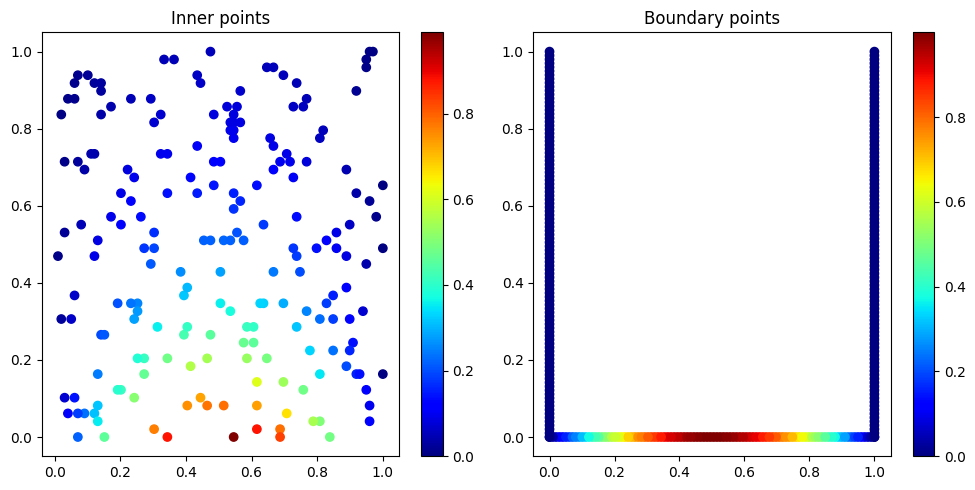

In [67]:
train_batch = Batch(data)

t_b = np.linspace(data.tmin, data.tmax, 100)
x_left = np.zeros_like(t_b)
u_left = np.zeros_like(t_b)
left_bc = Batch_bc(x_left, t_b, u_left)

x_right = np.ones_like(t_b) * data.xmax
u_right = np.zeros_like(t_b)
right_bc = Batch_bc(x_right, t_b, u_right)

x_in = np.linspace(data.xmin, data.xmax, 100)
t_in = np.zeros_like(x_in)
u_in = np.sin(data.n * np.pi * x_in / data.m)
initial_bc = Batch_bc(x_in, t_in, u_in)

train_batch.generate_points(200)
initial_bc.generate_points(100)
left_bc.generate_points(100)
right_bc.generate_points(100)

fig, ax=plt.subplots(1, 2, figsize=(10, 5))

pts = train_batch.points.detach().cpu().numpy()
vals = train_batch.values.detach().cpu().numpy()
i=0
f=ax[i].scatter(pts[:, 0], pts[:, 1], c=vals, cmap='jet')
plt.colorbar(f, ax=ax[i])
ax[i].set_title('Inner points')

pts_bc = np.vstack([initial_bc.points.detach().cpu().numpy(),
                    left_bc.points.detach().cpu().numpy(),
                    right_bc.points.detach().cpu().numpy()])
vals_bc = np.vstack([initial_bc.values.detach().cpu().numpy(),
                     left_bc.values.detach().cpu().numpy(),
                     right_bc.values.detach().cpu().numpy()])
i=1
f=ax[i].scatter(pts_bc[:, 0], pts_bc[:, 1], c=vals_bc, cmap='jet')
plt.colorbar(f, ax=ax[i])
ax[i].set_title('Boundary points')

plt.tight_layout()
plt.show()

In [68]:
trPs = TrainParams()
trPs.alpha = 0.3

trPs.batch = train_batch
trPs.init_bc = initial_bc
trPs.right_bc = right_bc
trPs.left_bc = left_bc

trPs.numPoints = 200
trPs.numBCPoints = 100
trPs.numEpoch = 10000

In [69]:
model = SomeModel(input_size=2, nnodes=10, nlayers=4, activation=nn.Tanh()).to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.001)

lambda1 = lambda epoch: 0.999**epoch
scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lambda1)

lrs = []
hist_loss = []

In [70]:
train(model, opt, scheduler, trPs)

Step: 9998 | Loss: 0.2229294032: 100%|██████████| 10000/10000 [01:02<00:00, 160.25it/s]


0

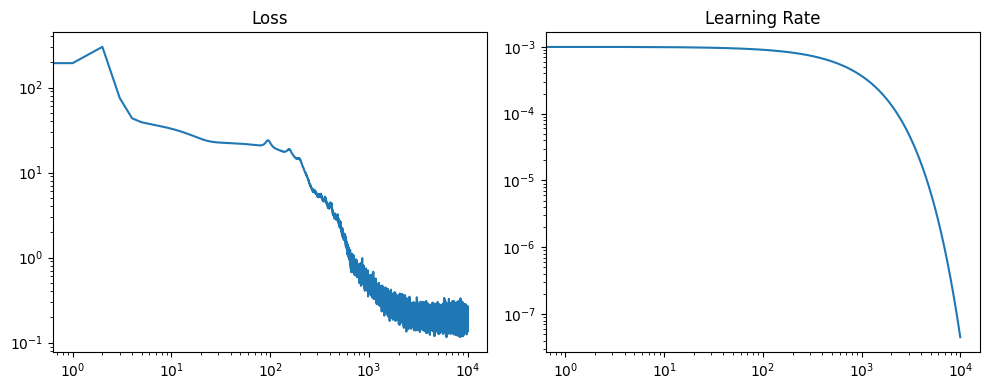

In [71]:
fig, ax= plt.subplots(1,2, figsize=(10,4))

i=0
ax[i].plot(hist_loss)
ax[i].set_xscale('log')
ax[i].set_yscale('log')
ax[i].set_title('Loss')

i=1
ax[i].plot(lrs)
ax[i].set_xscale('log')
ax[i].set_yscale('log')
ax[i].set_title('Learning Rate')

plt.tight_layout()
plt.show()

In [72]:
x_flat = data.x.flatten()
t_flat = data.t.flatten()
grid_pred = torch.from_numpy(np.vstack((x_flat, t_flat)).T).float().to(device)

pred = model(grid_pred).detach().cpu().numpy().reshape(data.x.shape)

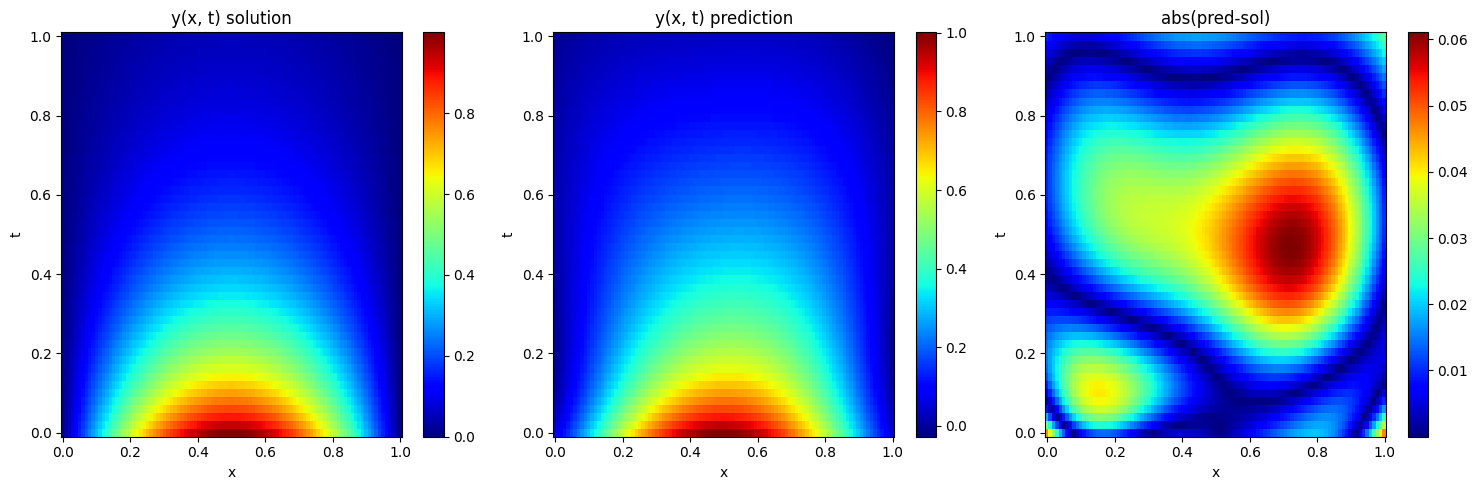

In [73]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

i=0
f=ax[i].pcolor(data.x, data.t, data.solution, cmap='jet', shading='auto')
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('y(x, t) solution')

i=1
f=ax[i].pcolor(data.x, data.t, pred, cmap='jet', shading='auto')
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('y(x, t) prediction')

i=2
diff = np.abs(pred - data.solution)
f=ax[i].pcolor(data.x, data.t, diff, cmap='jet', shading='auto')
plt.colorbar(f, ax=ax[i])
ax[i].set_xlabel('x')
ax[i].set_ylabel('t')
ax[i].set_title('abs(pred-sol)')

plt.tight_layout()
plt.show()